В данной работе проводится обработка результатов расчета напряженно-деформированного состояния (НДС) тонкостенного трубчатого образца при сложном нагружении по винтовой траектории.

**Материал:** Сталь 45 (Модель билинейного изотропного упрочнения - **BISO**).

**Цель:** Анализ векторных и скалярных свойств материала, проверка корректности моделирования в ANSYS.

In [1]:
model_name = "BISO"

In [2]:
from core.reader import read_ansys_csv

numerical_experiment_data_biso = r'biso.csv'
numerical_experiment_biso = read_ansys_csv(numerical_experiment_data_biso)

### 1. Первичный обзор данных
Проверим структуру загруженного DataFrame. Данные содержат временные метки, компоненты тензоров деформаций (упругих `EPEL`, пластических `EPPL`, полных `EPTO`), напряжений (`S`), а также интенсивность деформаций и параметр Одквиста.

In [13]:
numerical_experiment_biso.sample(10, random_state=42)

,Time,EPEL_TT,EPPL_TT,EPTO_TT,EPEL_ZZ,EPPL_ZZ,EPTO_ZZ,EPEL_TZ,EPPL_TZ,EPTO_TZ,EPEL_RR,EPPL_RR,EPTO_RR,S_TT,S_ZZ,S_TZ,S_EQV,EPPL_EQV,NL_EPEQ
0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.00000,0.00000,0.0000,0.000000,0.000000
5,5.0,0.000291,-0.000291,0.000000,0.001875,0.001875,0.003750,0.000000,0.000000,0.000000,-0.000885,-0.001584,-0.002469,186.7978,438.60620,0.00000,381.2324,0.002018,0.002020
46,46.0,0.003279,0.018713,0.021991,-0.001105,0.003780,0.002676,-0.001303,0.002897,0.001594,-0.000888,-0.022493,-0.023381,662.1307,-34.48544,-103.56020,703.2882,0.024147,0.032654
31,31.0,0.001657,0.010344,0.012001,0.002292,0.004047,0.006340,-0.000471,-0.003185,-0.003656,-0.001613,-0.014392,-0.016005,519.6740,620.64710,-37.40668,580.4545,0.014957,0.020970
13,13.0,0.001696,0.000274,0.001970,0.000676,0.006146,0.006822,0.001741,0.001223,0.002964,-0.000969,-0.006420,-0.007389,423.6111,261.48800,138.35380,440.9971,0.007294,0.007705
55,55.0,0.002484,0.022853,0.025338,0.002442,0.003330,0.005773,-0.002008,-0.002110,-0.004118,-0.002012,-0.026183,-0.028196,714.6041,707.92490,-159.55300,763.0872,0.028532,0.038342
34,34.0,0.001869,0.011223,0.013092,0.002049,0.005372,0.007421,0.001534,-0.002610,-0.001077,-0.001600,-0.016595,-0.018196,551.3487,579.97770,121.85900,604.2668,0.017002,0.023235
49,49.0,0.003023,0.020600,0.023623,-0.000255,0.002931,0.002676,-0.002934,0.001340,-0.001594,-0.001130,-0.023531,-0.024661,660.0406,139.08890,-233.14540,725.4415,0.025659,0.034762
12,12.0,0.001408,-0.000166,0.001242,0.001208,0.005983,0.007191,0.001530,0.000556,0.002086,-0.001068,-0.005817,-0.006886,393.5455,361.72700,121.59090,433.2683,0.006822,0.006969
40,40.0,0.002861,0.014318,0.017180,-0.000204,0.005977,0.005773,0.002345,0.001773,0.004118,-0.001085,-0.020295,-0.021380,627.1548,140.02510,186.34450,655.1989,0.020884,0.028080


### 2. Графики полных деформаций
Построим графики изменения компонент тензора полных деформаций от времени.
* `EPTO_ZZ` — осевая деформация ($\varepsilon_z$).
* `EPTO_TT` — окружная деформация ($\varepsilon_\theta$).
* `EPTO_TZ` — деформация сдвига ($\varepsilon_{\theta z}$).

На первом этапе (растяжение) должна меняться только $\varepsilon_z$. На втором этапе (винт) должны меняться все компоненты.

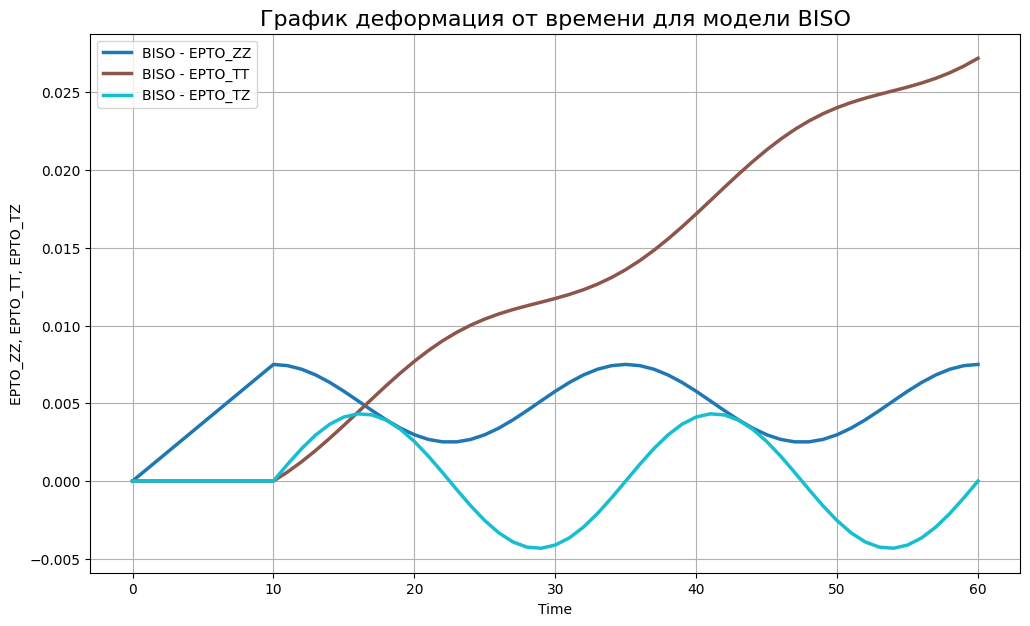

In [4]:
from core.visualizer import plot_xy

plot_xy([
        (model_name, numerical_experiment_biso)
    ],
    'Time',
    ['EPTO_ZZ', 'EPTO_TT', 'EPTO_TZ'],
    f'График деформация от времени для модели {model_name}'
)


### 3. Расчет вектора деформаций Ильюшина
Для анализа сложных процессов деформирования перейдем от тензорного представления к векторному в пятимерном евклидовом пространстве А.А. Ильюшина $E^5$.

Компоненты вектора деформаций $\bar{\ni}$ линейно выражаются через компоненты тензора деформаций. Для случая тонкостенного трубчатого образца (где $\varepsilon_{11} = \varepsilon_z$ — осевая, $\varepsilon_{22} = \varepsilon_\theta$ — окружная, $\varepsilon_{12} = \varepsilon_{\theta z}$ — сдвиговая) формулы принимают вид:

$$ \ni_1 = \varepsilon_z - \varepsilon_{mean}$$
$$ \ni_2 = \frac{1}{\sqrt{3}} ((\varepsilon_z - \varepsilon_{mean}) + 2(\varepsilon_\theta - \varepsilon_{mean})) $$
$$ \ni_3 = \frac{2}{\sqrt{3}} \varepsilon_{\theta z} $$

Это позволяет нам анализировать траекторию деформирования как кривую в векторном пространстве, вычислять ее кривизну и угол сближения.

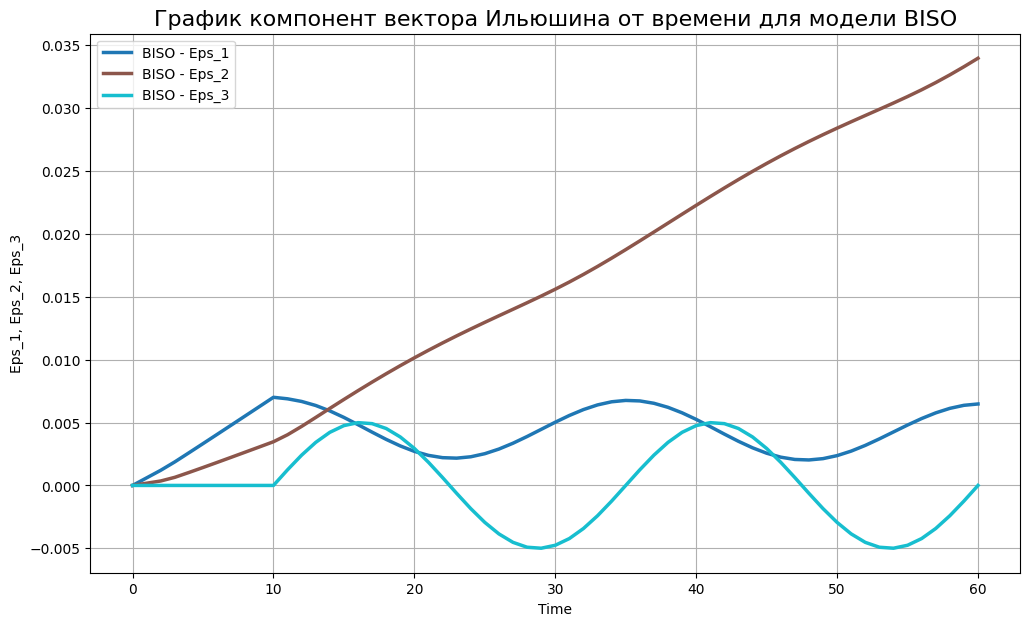

In [5]:
from core.calculations import calculate_ilushin_strain_vector


numerical_experiment_biso_strain_vector = calculate_ilushin_strain_vector(numerical_experiment_biso)
plot_xy([
        (model_name, numerical_experiment_biso_strain_vector)
    ],
    'Time',
    ['Eps_1', 'Eps_2', 'Eps_3'],
    f'График компонент вектора Ильюшина от времени для модели {model_name}'
)

### 4. Разделение этапов деформирования
Процесс нагружения состоит из двух этапов:
1.  **Одноосное растяжение** (прямолинейный участок траектории).
2.  **Сложное нагружение** (винтовая траектория).

Нам необходимо выделить данные, относящиеся только ко второму этапу, так как именно на нем исследуются эффекты сложного деформирования (кручение, кривизна траектории). Момент окончания первого этапа считываем из файла конфигурации `steps_n1.txt`.

In [6]:
step_n1_path = r'steps_n1.txt'
with open(step_n1_path, 'r') as f:
        split_time = float(f.read().strip())
split_time

10.0

In [7]:
df_stage2 = numerical_experiment_biso_strain_vector[
    numerical_experiment_biso_strain_vector['Time'] > split_time
].copy()

df_stage2.reset_index(drop=True, inplace=True)
df_stage2['Time_Local'] = df_stage2['Time'] - split_time

In [8]:
df_stage2[:10]

,Time,Eps_1,Eps_2,Eps_3,Time_Local
0,11.0,0.006885,0.004028,0.001243,1.0
1,12.0,0.006675,0.004693,0.002409,2.0
2,13.0,0.006355,0.005404,0.003423,3.0
3,14.0,0.005924,0.006122,0.004222,4.0
4,15.0,0.005405,0.006834,0.004755,5.0
5,16.0,0.004830,0.007532,0.004990,6.0
6,17.0,0.004236,0.008213,0.004911,7.0
7,18.0,0.003660,0.008877,0.004524,8.0
8,19.0,0.003140,0.009520,0.003853,9.0
9,20.0,0.002707,0.010142,0.002939,10.0


### 5. Аналитическое решение для скоростей деформаций

Для проверки точности численных методов и нейросети мы используем аналитическое решение. Траектория деформирования на втором этапе представляет собой винтовую линию и задается следующими параметрическими уравнениями зависимости деформаций от угла поворота $\alpha$:

**1. Уравнения траектории (зависимость от $\alpha$):**
$$ \varepsilon_z(\alpha) = c \cdot (\cos\alpha - 1) + \varepsilon_{z_0} $$
$$ \varepsilon_\theta(\alpha) = \frac{\sqrt{3}}{2} a \left(\frac{\alpha}{2\pi}\right) - \frac{1}{2} c \cdot (\cos\alpha - 1) $$
$$ \varepsilon_{\theta z}(\alpha) = \frac{\sqrt{3}}{2} c \cdot \sin\alpha $$

где:
*   $c$ — радиус цилиндра траектории в пространстве деформаций.
*   $a$ — шаг винтовой линии.
*   $\alpha(t) = \omega \cdot t$ — угол поворота, линейно зависящий от времени ($\omega = const$).

**2. Скорости деформаций (производные по времени):**
Дифференцируя уравнения траектории по времени ($\frac{d}{dt} = \frac{d}{d\alpha} \frac{d\alpha}{dt}$), получаем:

$$ \dot{\varepsilon}_z = -c \cdot \sin\alpha \cdot \omega $$
$$ \dot{\varepsilon}_\theta = \left( \frac{\sqrt{3} a}{4\pi} + \frac{1}{2} c \cdot \sin\alpha \right) \cdot \omega $$
$$ \dot{\varepsilon}_{\theta z} = \frac{\sqrt{3}}{2} c \cdot \cos\alpha \cdot \omega $$

**3. Вектор скоростей деформаций Ильюшина:**

Для тонкостенной трубки мы принимаем гипотезу **плоского напряженного состояния** ($\sigma_r = 0$).

1. **Связь радиальной деформации с остальными:**
    Из закона Гука следует, что деформация по толщине стенки ($\varepsilon_r$) зависит от осевой ($\varepsilon_z$) и окружной ($\varepsilon_\theta$):
    $$ \varepsilon_r = -\frac{\nu}{1-\nu} (\varepsilon_z + \varepsilon_\theta) $$

2.  **Средняя деформация (изменение объема):**
    $$ \varepsilon_{mean} = \frac{1}{3} (\varepsilon_z + \varepsilon_\theta + \varepsilon_r) $$
    Подставив $\varepsilon_r$, получаем:
    $$ \varepsilon_{mean} = \frac{1-2\nu}{3(1-\nu)} (\varepsilon_z + \varepsilon_\theta) $$

3.  **Вектор скоростей Ильюшина:**
    Подставляя найденные производные в формулы связи векторного и тензорного представлений, получаем итоговые выражения для компонент вектора скорости $\dot{\bar{\ni}}$:

    $$ \dot{\ni}_1 = \dot{\varepsilon}_z - \dot{\varepsilon}_{mean} $$
    
    $$ \dot{\ni}_2 = \frac{1}{\sqrt{3}} \left[ (\dot{\varepsilon}_z - \dot{\varepsilon}_{mean}) + 2(\dot{\varepsilon}_\theta - \dot{\varepsilon}_{mean}) \right] = \frac{1}{\sqrt{3}} (\dot{\varepsilon}_z + 2\dot{\varepsilon}_\theta - 3\dot{\varepsilon}_{mean}) $$
    
    $$ \dot{\ni}_3 = \frac{2}{\sqrt{3}} \dot{\varepsilon}_{\theta z} $$

Эти формулы позволяют вычислить точное значение производной в любой точке $t$ и использовать его как эталон для оценки ошибки MSE.

In [9]:
step_n2_path = r'steps_n2.txt'
with open(step_n2_path, 'r') as f:
        steps_n2 = float(f.read().strip())
steps_n2

50.0

Угловая скорость на винтовой траектории omega: 0.2513


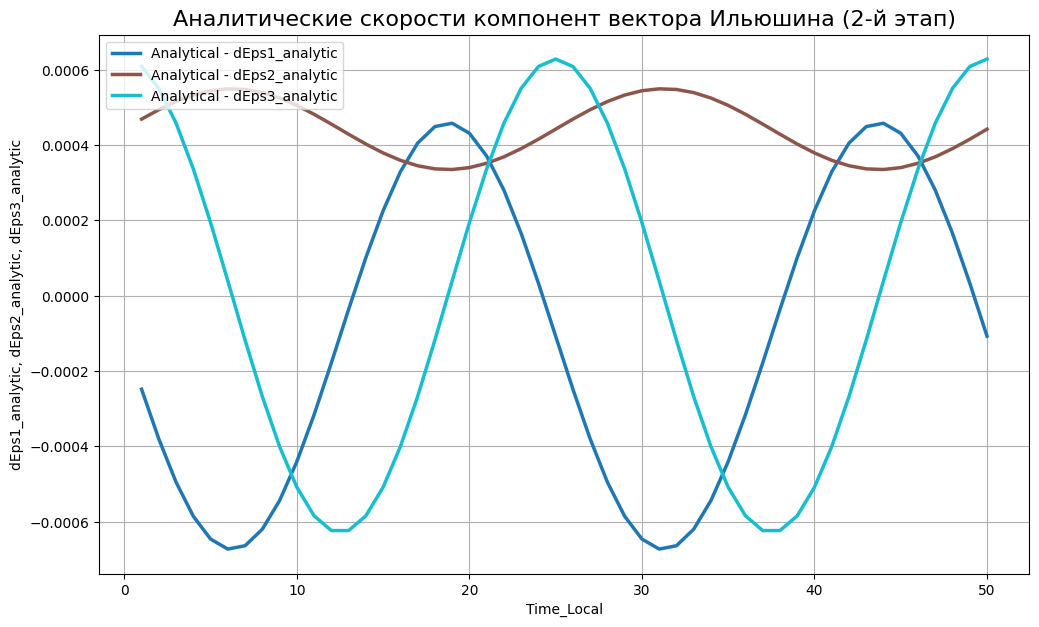

In [10]:
from core.derivatives.analytical import AnalyticalDerivatives


analytical = AnalyticalDerivatives(
    c=25e-4, 
    a=157e-4, 
    n_turns=2.0, 
    duration=steps_n2
)

print(f"Угловая скорость на винтовой траектории omega: {analytical.omega:.4f}")

t_vals = df_stage2['Time_Local'].values
dE1_analytic, dE2_analytic, dE3_analytic = analytical.get_derivatives(t_vals)
df_stage2['dEps1_analytic'] = dE1_analytic
df_stage2['dEps2_analytic'] = dE2_analytic
df_stage2['dEps3_analytic'] = dE3_analytic

plot_xy(
    data_pairs=[
        ('Analytical', df_stage2)
    ],
    x_col='Time_Local',
    y_cols=['dEps1_analytic', 'dEps2_analytic', 'dEps3_analytic'],
    title='Аналитические скорости компонент вектора Ильюшина (2-й этап)'
)